# 인공지능수학 1주차 — 벡터, 행렬, 그리고 NumPy

**강의 시간:** 75분 (이론 50분 + 익히기 25분)

---

## 🎯 오늘의 목표

1. 벡터와 행렬이 AI에서 데이터를 표현하는 언어임을 이해한다
2. NumPy 배열의 shape을 자유롭게 다룬다
3. 인덱싱·슬라이싱·불리언·팬시 인덱싱을 직접 써본다
4. Broadcasting으로 정규화를 구현한다

In [2]:
import numpy as np
import matplotlib.pyplot as plt

---
# Part 1. 왜 벡터와 행렬인가?

아파트 가격을 예측하려면 데이터가 필요합니다.

| 면적(m²) | 역까지 거리(분) | 가격(만원) |
|:---:|:---:|:---:|
| 84 | 10 | 65,000 |
| 59 | 5  | 52,000 |
| 112 | 20 | 71,000 |

- 각 행 (아파트 한 채) = **벡터**
- 전체 표 = **행렬**

AI 모델은 이 표를 통째로 받아서 계산합니다. 그 계산의 언어가 **선형대수**입니다.

---
# Part 2. 벡터(Vector)

## 2-1. 정의와 표기

$$\mathbf{x} = \begin{bmatrix} 84 \\ 10 \end{bmatrix} \in \mathbb{R}^2$$

- $\mathbb{R}^n$: $n$개의 실수로 이루어진 공간
- 기본적으로 **열벡터(column vector)** 로 표기

## 2-2. 벡터 연산

### ① 덧셈 / 스칼라 곱

$$\mathbf{a} + \mathbf{b} = \begin{bmatrix} 3 \\ 2 \end{bmatrix} + \begin{bmatrix} 1 \\ 4 \end{bmatrix} = \begin{bmatrix} 4 \\ 6 \end{bmatrix}, \qquad 3\mathbf{a} = \begin{bmatrix} 9 \\ 6 \end{bmatrix}$$

### ② 내적 (Dot Product) ⭐

$$\mathbf{a} \cdot \mathbf{b} = \mathbf{a}^T \mathbf{b} = \sum_{i} a_i b_i = 3 \times 1 + 2 \times 4 = 11$$

결과는 **스칼라(숫자 하나)**.  
> **AI 연결:** 선형회귀 예측값 $\hat{y} = \mathbf{w}^T\mathbf{x}$ 가 내적입니다.

In [ ]:
a = np.array([3, 2])
b = np.array([1, 4])

print(a.shape) # (원소개수, )


print("a + b        =", a + b)
print("3 * a        =", 3 * a)
print("a · b (dot)  =", np.dot(a, b))       # 11
print("a · b (@)    =", a @ b)              # same
print("||a|| (norm) =", np.linalg.norm(a))  # sqrt(13)

(2,)
a + b        = [4 6]
3 * a        = [9 6]
a · b (dot)  = 11
a · b (@)    = 11
||a|| (norm) = 3.605551275463989


---
# Part 3. 행렬(Matrix)

## 3-1. 정의

$$X = \begin{bmatrix} 84 & 10 \\ 59 & 5 \\ 112 & 20 \end{bmatrix} \in \mathbb{R}^{3 \times 2}$$

- **shape:** $(m, n)$ = $m$행 $n$열
- 각 행 = 샘플 하나 / 각 열 = 특성 하나

## 3-2. 행렬 곱셈 ⭐

$$A_{m \times k} \cdot B_{k \times n} = C_{m \times n}$$

**핵심 규칙:** 앞 행렬의 **열 수** = 뒤 행렬의 **행 수**  
$C_{ij}$ = $A$의 $i$행과 $B$의 $j$열의 **내적**

> **AI 연결:** $\hat{\mathbf{y}} = X\mathbf{w}$ — 행렬 곱 한 번으로 모든 샘플을 한꺼번에 예측

In [4]:
X = np.array([[84,  10],
              [59,   5],
              [112, 20]])   # shape (3, 2)

w = np.array([[300],
              [-200]])      # shape (2, 1)

y_hat = X @ w              # (3,2) @ (2,1) = (3,1)

print("X.shape   :", X.shape)
print("w.shape   :", w.shape)
print("y_hat.shape:", y_hat.shape)
print("Predicted prices (10k KRW):\n", y_hat)

X.shape   : (3, 2)
w.shape   : (2, 1)
y_hat.shape: (3, 1)
Predicted prices (10k KRW):
 [[23200]
 [16700]
 [29600]]


---
# Part 4. NumPy — 1D vs 2D 배열의 차이 ⭐

NumPy에서 가장 많이 실수하는 부분입니다. shape을 항상 확인하는 습관이 필요합니다.

## 4-1. 세 가지 형태 비교

| 이름 | 생성 | shape | 의미 |
|---|---|---|---|
| 1D 배열 | `np.array([1,2,3])` | `(3,)` | 그냥 숫자 묶음 |
| 행벡터 | `np.array([[1,2,3]])` | `(1,3)` | 1행 3열 행렬 |
| 열벡터 | `np.array([[1],[2],[3]])` | `(3,1)` | 3행 1열 행렬 |

In [5]:
a = np.array([1, 2, 3, 4, 5])           # 1D: shape (5,)
b = np.array([[1, 2, 3, 4, 5]])         # row vector: shape (1,5)
c = np.array([[1],[2],[3],[4],[5]])      # col vector: shape (5,1)

print("a        shape:", a.shape)    # (5,)
print("b (row)  shape:", b.shape)    # (1, 5)
print("c (col)  shape:", c.shape)    # (5, 1)

a        shape: (5,)
b (row)  shape: (1, 5)
c (col)  shape: (5, 1)


## 4-2. 전치(Transpose)의 차이

**1D 배열은 전치해도 shape이 변하지 않습니다.** 이게 가장 많이 헷갈리는 부분입니다.

In [6]:
print("a.T   shape:", a.T.shape)   # (5,)  ← 변화 없음!
print("b.T   shape:", b.T.shape)   # (5, 1)
print("c.T   shape:", c.T.shape)   # (1, 5)

print()
print("a     =", a)
print("a.T   =", a.T)   # 똑같이 보임 — 1D는 행/열 구분이 없습니다

a.T   shape: (5,)
b.T   shape: (5, 1)
c.T   shape: (1, 5)

a     = [1 2 3 4 5]
a.T   = [1 2 3 4 5]


## 4-3. 행렬 곱에서의 차이

shape이 다르면 `@` 연산 결과도 달라집니다.

In [7]:
# 1D @ 1D → scalar (내적)
print("a @ a  =", a @ a)              # 55  shape: scalar

# (1,5) @ (5,1) → (1,1)  (스칼라처럼 보이지만 행렬)
print("b @ c  =", b @ c)              # [[55]]  shape: (1,1)
print("       shape:", (b @ c).shape)

# (5,1) @ (1,5) → (5,5)  (outer product!)
print("c @ b  shape:", (c @ b).shape) # (5,5)

# shape 불일치 → 에러
try:
    b @ b   # (1,5) @ (1,5) — 앞의 열(5) ≠ 뒤의 행(1)
except ValueError as e:
    print("b @ b  → Error:", e)

a @ a  = 55
b @ c  = [[55]]
       shape: (1, 1)
c @ b  shape: (5, 5)
b @ b  → Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 5)


## 4-4. reshape으로 변환하기

1D 배열을 2D로 바꿀 때 자주 쓰는 세 가지 방법입니다.

In [ ]:
a = np.array([1, 2, 3, 4, 5])   # shape (5,)

# 열벡터로 만들기
print("reshape(-1, 1)    :", a.reshape(-1, 1).shape)   # (5, 1) => -1 : 자동지정
print("[:, np.newaxis]   :", a[:, np.newaxis].shape)   # (5, 1)
print("reshape(5, 1)     :", a.reshape(5, 1).shape)    # (5, 1)

# 행벡터로 만들기
print("reshape(1, -1)    :", a.reshape(1, -1).shape)   # (1, 5)
print("[np.newaxis, :]   :", a[np.newaxis, :].shape)   # (1, 5)

print()
print("Tip: -1 means 'infer this dimension automatically'")
print("     reshape(-1, 1) = 'make it a column vector, however many rows needed'")

reshape(-1, 1)    : (5, 1)
[:, np.newaxis]   : (5, 1)
reshape(5, 1)     : (5, 1)
reshape(1, -1)    : (1, 5)
[np.newaxis, :]   : (1, 5)

Tip: -1 means 'infer this dimension automatically'
     reshape(-1, 1) = 'make it a column vector, however many rows needed'


## 4-5. 언제 1D, 언제 2D를 쓰는가

| 상황 | 권장 shape | 이유 |
|---|---|---|
| 단순 숫자 묶음 | `(n,)` | 직관적, 가볍다 |
| 행렬 곱에 쓸 열벡터 | `(n, 1)` | `A @ w` 에서 shape 규칙 |
| 여러 샘플 데이터 | `(m, n)` | 행=샘플, 열=특성 |
| 정규방정식 $X^TX$ | `(m, n)` | 전치·곱 모두 정상 작동 |

> **습관:** 모르면 `print(x.shape)` 먼저 치세요.

---
# Part 5. NumPy 배열 만들기

In [ ]:
print(np.zeros((3, 4)))          # 3x4 zeros
print(np.ones((2, 3)))           # 2x3 ones
print(np.arange(0, 10, 2))      # [0 2 4 6 8]
print(np.linspace(0, 1, 5))     # 5 evenly spaced in [0,1]
print(np.eye(3))                 # 3x3 identity matrix -> 단위행렬! I?
print(np.random.randn(2, 3).round(2))  # standard distribution normal

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1. 1. 1.]
 [1. 1. 1.]]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[ 1.64  0.56 -0.22]
 [-0.13  0.96 -0.09]]


---
# Part 6. 인덱싱과 슬라이싱 ⭐

NumPy 배열에서 원하는 부분만 꺼내는 방법입니다.

## 6-1. 기본 인덱싱

In [18]:
X = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90],
              [11, 22, 33]])
print("X =\n", X)
print("shape:", X.shape, "→ 4 rows, 3 cols")

X =
 [[10 20 30]
 [40 50 60]
 [70 80 90]
 [11 22 33]]
shape: (4, 3) → 4 rows, 3 cols


In [10]:
# Single element
print("X[1, 2]    =", X[1, 2])       # row1, col2 → 60
print("X[0, 0]    =", X[0, 0])       # 10
print("X[-1, -1]  =", X[-1, -1])     # last row, last col → 33 => -1 : 여기서는 마지막거 말하는것

# Entire row / column
print("X[0]       =", X[0])          # first row → [10 20 30]
print("X[-1]      =", X[-1])         # last row
print("X[:, 1]    =", X[:, 1])       # second column → [20 50 80 22]
print("X[-1] =", X[-1])
print(X[:, 1].shape)

X[1, 2]    = 60
X[0, 0]    = 10
X[-1, -1]  = 33
X[0]       = [10 20 30]
X[-1]      = [11 22 33]
X[:, 1]    = [20 50 80 22]
X[-1] = [11 22 33]
(4,)


## 6-2. 슬라이싱

`start:stop:step` — stop은 **포함하지 않음**

In [17]:
print("X[1:3]       =\n", X[1:3])       # rows 1,2
print("X[:, 0:2]    =\n", X[:, 0:2])    # first 2 cols
print("X[1:3, 0:2]  =\n", X[1:3, 0:2]) # submatrix
print("X[::2]       =\n", X[::2])       # every other row
print("X[::-1]      =\n", X[::-1])      # reversed rows

X[1:3]       =
 [[ 59.   5.]
 [112.  20.]]
X[:, 0:2]    =
 [[ 84.  10.]
 [ 59.   5.]
 [112.  20.]]
X[1:3, 0:2]  =
 [[ 59.   5.]
 [112.  20.]]
X[::2]       =
 [[ 84.  10.]
 [112.  20.]]
X[::-1]      =
 [[112.  20.]
 [ 59.   5.]
 [ 84.  10.]]


## 6-3. 불리언 인덱싱 (Boolean Indexing) ⭐

조건을 만족하는 원소만 꺼냅니다. AI에서 데이터 필터링에 매우 자주 씁니다.

In [14]:
# Step 1: 조건식은 bool 배열을 반환합니다
mask = X > 40
print("X > 40:\n", mask)
print("dtype:", mask.dtype)   # bool

X > 40:
 [[False False False]
 [False  True  True]
 [ True  True  True]
 [False False False]]
dtype: bool


In [16]:
# Step 2: bool 배열로 인덱싱 → True인 원소만 1D로 추출
print("X[X > 40]  =", X[X > 40])   # [50 60 70 80 90]

# 값 수정도 가능
X_copy = X.copy()
X_copy[X_copy > 50] = 0
print("X_copy (>50 → 0):\n", X_copy)

X[X > 40]  = [50 60 70 80 90]
X_copy (>50 → 0):
 [[10 20 30]
 [40 50  0]
 [ 0  0  0]
 [11 22 33]]


In [18]:
# 행 단위 필터링 — AI에서 가장 많이 쓰는 패턴
# "첫 번째 열이 40보다 큰 행만 가져오기"
row_mask = X[:, 0] > 40
print("row_mask  :", row_mask)         # [F T T F]
print("X[row_mask]:\n", X[row_mask])   # rows where col0 > 40

# 복합 조건: & (and), | (or), ~ (not)
mask2 = (X[:, 0] > 20) & (X[:, 1] < 80)
print("\ncol0>20 AND col1<80:\n", X[mask2])

row_mask  : [False False  True False]
X[row_mask]:
 [[70 80 90]]

col0>20 AND col1<80:
 [[40 50 60]]


## 6-4. 팬시 인덱싱 (Fancy Indexing) ⭐

인덱스 배열로 원하는 행·열을 자유롭게 선택합니다.

In [19]:
# 행 선택 — 원하는 행 번호를 리스트로
print(X)
print("X[[0, 2, 3]] =\n", X[[0, 2, 3]])    # rows 0,2,3
print("X[[2, 0]]    =\n", X[[2, 0]])        # 순서도 바꿀 수 있음

[[10 20 30]
 [40 50 60]
 [70 80 90]
 [11 22 33]]
X[[0, 2, 3]] =
 [[10 20 30]
 [70 80 90]
 [11 22 33]]
X[[2, 0]]    =
 [[70 80 90]
 [10 20 30]]


In [20]:
# 열 선택 및 순서 변경
print("X[:, [2, 0]]   =\n", X[:, [2, 0]])   # col2, col0 순으로
print("X[:, [1, 1, 0]] =\n", X[:, [1,1,0]]) # 같은 열을 여러 번도 가능

X[:, [2, 0]]   =
 [[30 10]
 [60 40]
 [90 70]
 [33 11]]
X[:, [1, 1, 0]] =
 [[20 20 10]
 [50 50 40]
 [80 80 70]
 [22 22 11]]


In [21]:
# 행·열 동시 지정 — 쌍으로 선택됩니다
rows = np.array([0, 1, 2])
cols = np.array([2, 1, 0])
print("X[rows, cols] =", X[rows, cols])   # X[0,2], X[1,1], X[2,0] → [30 50 70]

# 활용: 각 행에서 특정 열의 값을 추출
# 예: 샘플별로 예측된 클래스의 확률을 꺼낼 때
probs = np.array([[0.1, 0.7, 0.2],
                  [0.8, 0.1, 0.1],
                  [0.3, 0.3, 0.4]])
predicted_class = np.array([1, 0, 2])   # 각 샘플의 예측 클래스
print("\nCorrect class prob:",
      probs[np.arange(3), predicted_class])  # [0.7, 0.8, 0.4]

X[rows, cols] = [30 50 70]

Correct class prob: [0.7 0.8 0.4]


## 6-5. 인덱싱 방법 비교 정리

| 방법 | 예시 | 결과 | 쓰는 상황 |
|---|---|---|---|
| 기본 | `X[1, 2]` | 스칼라 | 특정 원소 하나 |
| 슬라이싱 | `X[1:3, 0:2]` | 부분 행렬 | 연속된 범위 |
| 불리언 | `X[X > 0]` | 1D 배열 | 조건 필터링 |
| 팬시 | `X[[0,2,3]]` | 선택된 행들 | 불연속 행·열 선택 |

---
# Part 7. Broadcasting ⭐

크기가 다른 배열끼리 연산할 때 NumPy가 자동으로 크기를 맞춰주는 기능입니다.

## 7-1. 규칙

뒤쪽 차원부터 비교해서, **크기가 1이거나 같으면** 자동 확장합니다.

```
(4, 3)  -  (3,)   → (3,)가 (1,3) → (4,3) 으로 확장  ✅
(4, 1)  +  (1, 3) → 각각 (4,3) 으로 확장             ✅
(4, 3)  +  (4,)   → 마지막 차원 3 ≠ 4                ❌
```

In [22]:
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10,11,12]])   # shape (4, 3)

v = np.array([10, 20, 30])   # shape (3,)

# v가 (1,3) → (4,3) 으로 자동 확장됩니다
print("A - v =\n", A - v)
print("shape:", (A - v).shape)

A - v =
 [[ -9 -18 -27]
 [ -6 -15 -24]
 [ -3 -12 -21]
 [  0  -9 -18]]
shape: (4, 3)


In [23]:
# (4,1) + (1,3) → 각각 확장 → (4,3)
col = np.array([[1],[2],[3],[4]])    # (4, 1)
row = np.array([[10, 20, 30]])       # (1, 3)
result = col + row
print("col + row =\n", result)
print("shape:", result.shape)   # (4, 3)

# 실패 예시
try:
    np.array([1,2,3,4]) + np.array([1,2,3])
except ValueError as e:
    print("\nFails:", e)

col + row =
 [[11 21 31]
 [12 22 32]
 [13 23 33]
 [14 24 34]]
shape: (4, 3)

Fails: operands could not be broadcast together with shapes (4,) (3,) 


## 7-2. Broadcasting 실전 적용 — Z-점수 정규화 ⭐

정규화는 Broadcasting의 가장 전형적인 활용 예입니다.

$$x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

- $\mu_j$: $j$번째 열(특성)의 평균
- $\sigma_j$: $j$번째 열의 표준편차

손으로 구현하면 $m$개 행에 같은 연산을 반복해야 하는데, Broadcasting으로 한 줄에 끝납니다.

In [ ]:
X = np.array([[84.0,  10.0],
              [59.0,   5.0],
              [112.0, 20.0],
              [76.0,  15.0]])   # shape (4, 2)
#             [면적, 거리]

# axis=0: 열 방향으로 찌그러짐 → 각 열의 통계량
mean = X.mean(axis=0)   # shape (2,)  ← 열별 평균
std  = X.std(axis=0)    # shape (2,)  ← 열별 표준편차

print("Column means:", mean.round(1))
print("Column stds :", std.round(1))

# Broadcasting: (4,2) - (2,) → (2,)가 (1,2) → (4,2) 로 자동 확장
X_norm = (X - mean) / std   # shape (4, 2)

print("\nNormalized X:\n", X_norm.round(3))
print("\nNew column means (≈ 0):", X_norm.mean(axis=0).round(10))
print("New column stds  (≈ 1):", X_norm.std(axis=0).round(10))

Column means: [82.8 12.5]
Column stds : [19.1  5.6]

Normalized X:
 [[ 0.065 -0.447]
 [-1.24  -1.342]
 [ 1.527  1.342]
 [-0.352  0.447]]

New column means (≈ 0): [0. 0.]
New column stds  (≈ 1): [1. 1.]


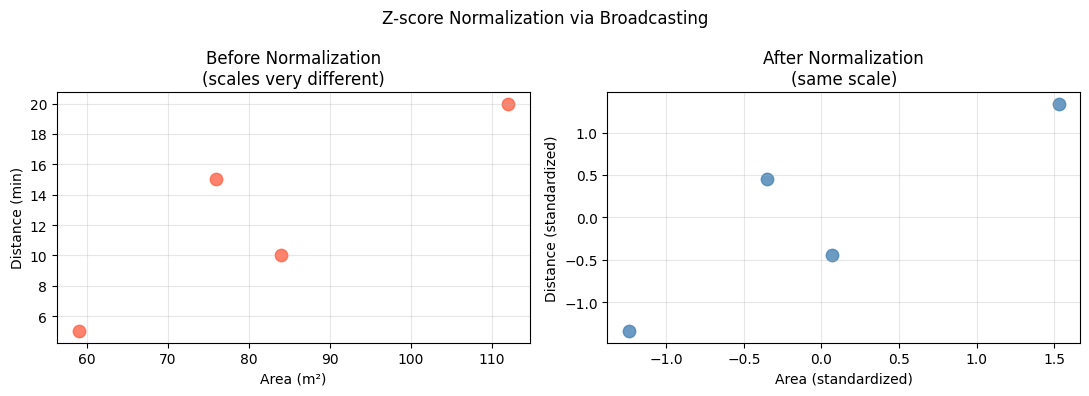

In [26]:
# Why normalization matters — scale comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(X[:, 0], X[:, 1], color='tomato', alpha=0.8, s=80)
axes[0].set_xlabel('Area (m²)')
axes[0].set_ylabel('Distance (min)')
axes[0].set_title('Before Normalization\n(scales very different)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_norm[:, 0], X_norm[:, 1], color='steelblue', alpha=0.8, s=80)
axes[1].set_xlabel('Area (standardized)')
axes[1].set_ylabel('Distance (standardized)')
axes[1].set_title('After Normalization\n(same scale)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Z-score Normalization via Broadcasting', fontsize=12)
plt.tight_layout()
plt.show()

> **왜 정규화가 필요한가?**  
> 면적(30-130)과 거리(1-60)의 스케일이 크게 다르면 학습이 불안정해집니다.  
> 이유는 2주차 손실함수와 3주차 경사하강법에서 자세히 다룹니다.

---
# 💡 모르는 함수가 나왔을 때

코드를 보다가 처음 보는 함수가 나오면 이 순서로 확인하세요.

**1단계: `type()`으로 반환값 확인** — 가장 빠름
```python
fig, ax = plt.subplots(figsize=(5, 5))
print(type(fig))   # <class 'matplotlib.figure.Figure'>
print(type(ax))    # <class 'matplotlib.axes.Axes'>
```

**2단계: `?`으로 docstring 확인** — Colab/Jupyter 내장
```python
plt.subplots?    # 짧은 설명
plt.subplots??   # 소스코드까지
```

**3단계: LLM에게 물어보기**
```
plt.subplots(figsize=(5,5)) 가 반환하는 fig와 ax가 각각 뭔지,
어떤 메서드를 주로 쓰는지 초보자 수준으로 설명해줘.
```

> **공식 문서(ref manual)** 는 사전처럼 쓰세요 — 처음부터 읽는 게 아니라 확인할 때 찾는 것입니다.

---
# ✏️ 익히기 활동 (25분)

---

## 활동 1. 인덱싱 (8분)

아래 배열에서 지정한 결과를 꺼내세요.

In [20]:
# Activity 1: indexing practice
A = np.array([[ 1,  2,  3,  4],
              [ 5,  6,  7,  8],
              [ 9, 10, 11, 12],
              [13, 14, 15, 16]])

# (1) 숫자 7을 꺼내세요
print("(1)", A[1,2])   # expected: 7

# (2) 마지막 행을 꺼내세요
print("(2)", A[-1])   # expected: [13 14 15 16]

# (3) 가운데 2x2 부분행렬을 꺼내세요
print("(3)\n", A[1:3, 1:3])  # expected: [[ 6  7][ 10 11]]

# (4) 50보다 큰 원소만 꺼내세요 (불리언)
# (없으면 (1)~(3) 먼저)
B = np.array([[10, 60], [30, 80], [50, 20]])
print("(4)", B[B>50])    # expected: [60 80]

(1) 7
(2) [13 14 15 16]
(3)
 [[ 6  7]
 [10 11]]
(4) [60 80]


## 활동 2. 1D vs 2D (7분)

In [21]:
# Activity 2: 1D vs 2D
v = np.array([1, 2, 3])   # shape (3,)

# (1) v를 열벡터 (3,1)로 만드세요 (두 가지 방법)
v_col_1 = v.reshape(-1, 1)   # reshape 사용
v_col_2 = v[:, np.newaxis]   # np.newaxis 사용
print("(1)", v_col_1.shape, v_col_2.shape)   # (3,1) (3,1)

# (2) 아래 두 연산의 결과 shape을 예측하고 확인하세요
W = np.ones((4, 3))
print("(2a) W @ v      shape:", (W @ v).shape)         # 예측: ?
print("(2b) W @ v_col_1 shape:", (W @ v_col_1).shape)  # 예측: ?

# (3) v.T와 v_col_1.T의 shape을 비교하세요
print("(3) v.T shape:", v.T.shape, "  v_col_1.T shape:", v_col_1.T.shape)

(1) (3, 1) (3, 1)
(2a) W @ v      shape: (4,)
(2b) W @ v_col_1 shape: (4, 1)
(3) v.T shape: (3,)   v_col_1.T shape: (1, 3)


## 활동 3. 🐛 버그 찾기 (10분)

아래 코드에 버그가 **2개** 있습니다. 실행 전에 찾아보세요.

In [22]:
# 🐛 Find 2 bugs before running

X = np.array([[84.0,  10.0],
              [59.0,   5.0],
              [112.0, 20.0]])

# Bug 1: axis direction
mean = X.mean(axis=0)     # ← intention: column-wise mean
std  = X.std(axis=0)
X_norm = (X - mean) / std

print(mean.shape)

# Bug 2: shape attribute vs method
print("shape:", X_norm.shape)   # ← shape is not a function

(2,)
shape: (3, 2)


In [23]:
# ✅ Fixed version
mean   = X.mean(axis=0)
std    = X.std(axis=0)
X_norm = (X - mean) / std

print("shape:", X.shape)
print("column means (≈ 0):", X_norm.mean(axis=0).round(10))
print("column stds  (≈ 1):", X_norm.std(axis=0).round(10))

shape: (3, 2)
column means (≈ 0): [0. 0.]
column stds  (≈ 1): [1. 1.]


---
# 📋 오늘 배운 것 체크리스트

- [ ] 내적 $\mathbf{a}^T\mathbf{b}$의 계산법을 안다
- [ ] 행렬 곱의 shape 규칙 (앞 열 = 뒤 행)을 안다
- [ ] 1D `(n,)` vs 열벡터 `(n,1)` vs 행벡터 `(1,n)`의 차이를 설명할 수 있다
- [ ] `reshape(-1,1)`과 `[:, np.newaxis]`로 1D → 2D로 바꿀 수 있다
- [ ] 기본·슬라이싱·불리언·팬시 인덱싱을 구분해서 쓸 수 있다
- [ ] Broadcasting 규칙을 이해하고 정규화에 적용할 수 있다
- [ ] `axis=0`이 열별 연산임을 안다

---
# 🤖 LLM 파트너 가이드

**① 개념 이해:**
```
NumPy에서 shape (5,)인 1D 배열과 shape (5,1)인 2D 배열의 차이를
행렬 곱셈에서 어떻게 다르게 동작하는지 예시 코드와 함께 설명해줘.
```

**② 인덱싱 심화:**
```
NumPy 불리언 인덱싱과 팬시 인덱싱의 차이를 설명하고,
각각 언제 쓰는 게 적합한지 실제 데이터 처리 예시로 보여줘.
```

**③ Broadcasting 규칙:**
```
NumPy broadcasting에서 shape (3,4)와 (4,)는 연산이 되는데
shape (3,4)와 (3,)은 안 되는 이유를 규칙과 함께 설명해줘.
```

---
# ➡️ 다음 주 예고

**2주차: 선형회귀 — 모델과 손실함수**

오늘 배운 $\hat{\mathbf{y}} = X\mathbf{w}$가 선형회귀의 전부입니다.  
다음 주 질문: **"가장 좋은 $\mathbf{w}$를 어떻게 찾는가?"**  
그리고 오늘 마지막에 나온 정규화가 왜 필요한지 수학적으로 설명합니다.